In [9]:
import os
import sys
import numpy as np
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
%matplotlib inline

Loading the test data with 5 more images from the city of Antsirabe, Madagascar (urban setting with dirt tracks)

In [6]:
import matplotlib
def test_data():
    data_dir = "D:/Cours EPFL/Projet ML/test_set_images/"
    imgs = []
    for i in range(1, 51):
        imageid = "test_{}".format(i)
        image_filename = data_dir + imageid + ".png"
        if os.path.isfile(image_filename):
            #print("Loading " + image_filename)
            img = mpimg.imread(image_filename)
            imgs.append(img)
        else:
            print("File " + image_filename + " does not exist")
    
    for i in range(1, 5):
        imageid = "C:/Users/Tistou/Pictures/Screenshots/Antsirabe_{}".format(i)
        image_filename = imageid + ".png"
        if os.path.isfile(image_filename):
            #print("Loading " + image_filename)
            img = mpimg.imread(image_filename)
            newimg=np.zeros((608,608,3))
            for j in range(608):
                for k in range(608):
                    newimg[j,k]=np.asarray(matplotlib.colors.colorConverter.to_rgb(img[j,k])) #convert from cmyk to rgb
            imgs.append(newimg)
    print(np.shape(imgs[0]),np.shape(imgs[52]))
    return np.asarray(imgs)

In [7]:
data_test = test_data()

(608, 608, 3) (608, 608, 3)


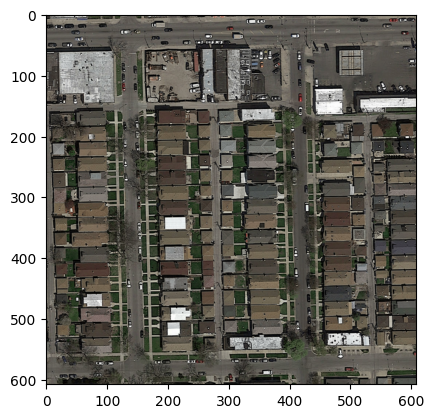

In [10]:
plt.imshow(data_test[0])

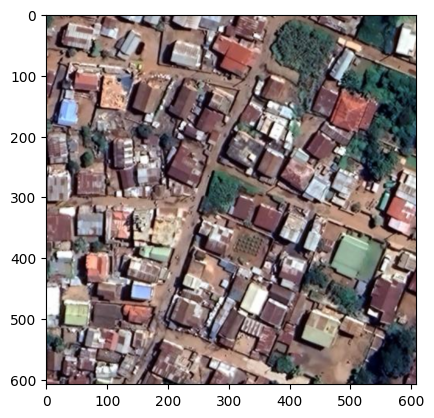

In [11]:
plt.imshow(data_test[52])

Data augmentation to include orange tracks in the training set, as well as images globally shifted towards orange

In [13]:
def extract_data_wo_patches(filename, num_images):
    """Extract the images into a 4D tensor [image index, y, x, channels].
    Values are rescaled from [0, 255] down to [-0.5, 0.5].
    """
    imgs = []
    for i in range(1, num_images + 1):
        imageid = "satImage_%.3d" % i
        image_filename = filename + imageid + ".png"
        if os.path.isfile(image_filename):
            #print("Loading " + image_filename)
            img = mpimg.imread(image_filename)
            imgs.append(img)
        else:
            print("File " + image_filename + " does not exist")
            
    return np.asarray(imgs)

In [14]:
TRAINING_SIZE = 100  # Size of the training data

def main():
    data_dir = "D:/Cours EPFL/Projet ML/training/"
    data_filename = data_dir + "images/"
    gt_filename = data_dir + "groundtruth/"

    # Extract it into numpy arrays.
    data = extract_data_wo_patches(data_filename, TRAINING_SIZE)
    labels = extract_data_wo_patches(gt_filename, TRAINING_SIZE)
    
    return data, labels

In [15]:
data, gt = main()
# Binarise the ground truth
ones=np.ones((100,400,400),dtype=np.short)

gt_bin = np.zeros((100,400,400),dtype=np.short)
gt_bin[gt > 0.25]=ones[gt > 0.25]

In [16]:
#For each image, we will include a copy with just the road in another color and a copy with everything shifted towards another color
col=[0.8,0.47,0.13] #ochre, everything is normalised to [0,1] instead of [0,255]

full_col=np.zeros((400,400,3),dtype=np.float32)
for i in range(400):
    for j in range(400):
        full_col[i][j]=col

def shift_to_col(im):
    return (im*3+full_col)/4 #taking a ponderate mean with a patch of the given color, shifts the image towards this color

data_col = np.zeros((3*len(data), 400, 400, 3),dtype=np.float32)
gt_col = np.zeros((3*len(data), 400, 400),dtype=np.float32)

for i in range(len(data)):
    data_col[3*i] = data[i]

    data_col[3*i+1][gt_bin[i]==False] = data[i][gt_bin[i]==False]
    data_col[3*i+1][gt_bin[i]==True] = (data[i][gt_bin[i]==True]*3+full_col[gt_bin[i]==True])/4 
    data_col[3*i+2] = shift_to_col(data[i])
    
    gt_col[3*i] = gt[i]
    gt_col[3*i+1] = gt[i]
    gt_col[3*i+2] = gt[i]

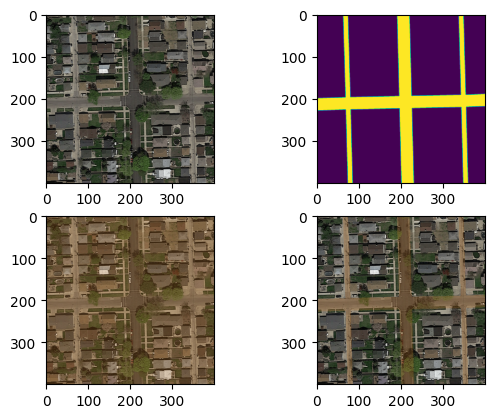

In [17]:
def display_quadruplet(i):
    image = data_col[3*i]
    road = gt_col[3*i]
    road_col = data_col[3*i+1]
    shift_col = data_col[3*i+2]
    plt.subplot(2, 2, 1)
    plt.imshow(image)
    plt.subplot(2, 2, 2)
    plt.imshow(road)
    plt.subplot(2, 2, 3)
    plt.imshow(shift_col)
    plt.subplot(2, 2, 4)
    plt.imshow(road_col)

display_quadruplet(0)

In [ ]:
# for each image, add its three rotated versions in data and gt
data_rot = np.zeros((4*len(data_col), 400, 400, 3),dtype=np.float16) #type float16 to use less memory
gt_rot = np.zeros((4*len(data_col), 400, 400),dtype=np.float16)

for i in range(len(data)):
    data_rot[4*i] = data_col[i]
    data_rot[4*i+1] = np.rot90(data_col[i])
    data_rot[4*i+2] = np.rot90(data_rot[4*i+1])
    data_rot[4*i+3] = np.rot90(data_rot[4*i+2])
    
    gt_rot[4*i] = gt_col[i]
    gt_rot[4*i+1] = np.rot90(gt_col[i])
    gt_rot[4*i+2] = np.rot90(gt_rot[4*i+1])
    gt_rot[4*i+3] = np.rot90(gt_rot[4*i+2])

# For each image, extract four 304x304 patches
n = len(data_rot)
data_patches = np.zeros((4*n, 304, 304, 3),dtype=np.float16)
gt_patches = np.zeros((4*n, 304, 304),dtype=np.float16)

for i in range(n):
    data_patches[i] = data_rot[i][0:304, 0:304, :]
    gt_patches[i] = gt_rot[i][0:304, 0:304]
    data_patches[n+i] = data_rot[i][96:400, 96:400, :]
    gt_patches[n+i] = gt_rot[i][96:400, 96:400]
    data_patches[2*n+i] = data_rot[i][0:304, 96:400, :]
    gt_patches[2*n+i] = gt_rot[i][0:304, 96:400]
    data_patches[3*n+i] = data_rot[i][96:400, 0:304, :]
    gt_patches[3*n+i] = gt_rot[i][96:400, 0:304]
    
# Shuffle the data
np.random.seed(10)
shuffle = list(range(len(data_patches)))
np.random.shuffle(shuffle)
data_shuffled = data_patches[shuffle]
gt_shuffled = gt_patches[shuffle]

# Split the data into training and validation sets
VALIDATION_SIZE = len(data_shuffled) // 5
validation_data = data_shuffled[:VALIDATION_SIZE, :, :, :] 
validation_gt = gt_shuffled[:VALIDATION_SIZE]
train_data = data_shuffled[VALIDATION_SIZE:, :, :, :]
train_gt = gt_shuffled[VALIDATION_SIZE:]

print("Training data shape: " + str(train_data.shape), "Validation data shape: " + str(validation_data.shape))
print("Training labels shape: " + str(train_gt.shape), "Validation labels shape: " + str(validation_gt.shape))